# Forest Cover Type Classification with a Neural Network

We begin by importing the Forest Cover type dataset. The dataset contains 581012 instances, each with 54 features, 10 of which are continuous, with the rest being binary. There are seven possible cover type classes, and they are not equally represented in the data; the class imbalance is severe.

In [12]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader 
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

These are the features in the dataset:

In [13]:
data = fetch_covtype()
print(data.feature_names)

['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_0', 'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3', 'Soil_Type_0', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11', 'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15', 'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36', 'Soil_Type_37', 'Soil_Type_38', 'Soil_Type_39']


We import the dataset and split into training (70%), validation (15%) and testing sets (15%). We standardise the first 10 features in the data since they are continuous. The scaler is fitted on the train data only, before all three sets are transformed. Also, we define a weights vector that will be employed by the model to take into account the imbalance in the classes.

In [14]:
torch.manual_seed(6)
X, y = data.data, data.target
y = [i-1 for i in y]
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=18)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.176471, random_state=24)

scaler = StandardScaler()

X_train_stand = X_train[:, :10]
X_train_bin = X_train[:, 10:]
X_train_stand = scaler.fit_transform(X_train_stand)
X_train = np.concatenate((X_train_stand, X_train_bin), axis=1)

X_valid_stand = X_valid[:, :10]
X_valid_bin = X_valid[:, 10:]
X_valid_stand = scaler.transform(X_valid_stand)
X_valid = np.concatenate((X_valid_stand, X_valid_bin), axis=1)

X_test_stand = X_test[:, :10]
X_test_bin = X_test[:, 10:]
X_test_stand = scaler.transform(X_test_stand)
X_test = np.concatenate((X_test_stand, X_test_bin), axis=1)

# define a weights vector that will account for the severely imbalanced classes in the data (define for training data only)
class_counts = np.bincount(y_train).astype(float)
counts_inv = 1 / class_counts
class_weights_norm = counts_inv / sum(counts_inv)
print("Class counts: {}".format(class_counts))
print("Class weights: {}". format(class_weights_norm))

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).long()
train_data = TensorDataset(X_train, y_train)

X_valid = torch.from_numpy(X_valid).float()
y_valid = torch.from_numpy(y_valid).long()
valid_data = TensorDataset(X_valid, y_valid)

X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).long()

batch_size = 512



Class counts: [148311. 198168.  25148.   1894.   6576.  12268.  14343.]
Class weights: [0.0076374  0.00571591 0.04504178 0.59805213 0.1722492  0.09233051
 0.07897307]


Now we will define the architecture of the neural network to be used. It consists of three hidden dense layers, each making use of batch normalisation and the ReLU activation function.

Batch normalisation is designed to stabilise and speed up neural network training by normalising layer pre-activations across a batch. It was initially introduced to tackle internal covariate shift which describes how the input distribution of a layer change during training due to the random nature of parameter initialisation and the natural variation of the input data. As parameters are updated, the distribution of outputs from each layer changes, propagating through the network and altering the distributions of inputs in subsequent layers. Over time, a layer will encounter and have to adapt to varying distributions of inputs, with the continuous shifting in data distribution complicating the training process. However, since its introduction studies have shown that batch normalisation does little to reduce internal covariate shift and is now thought to improve performance by smoothing the loss landscape. This leads to more stable behaviour of the gradients, and consequently permits higher learning rates.

Consider a mini-batch, $B$, consisting of $m$ instances. A layer of the network has input $x$ and first computes the affine transformation $z=Wx+b$ (which we will call the pre-activation), where $W$ is a weight matrix and $b$ is the bias. If we have an $n$-dimensional pre-activation, $z=(z^{(1)}, z^{(2)}, ..., z^{(n)})$, each of the dimensions is normalised separately according to
$$\hat{z}_i^{(k)} = \frac{z_i^{(k)} - \mu_B^{(k)}}{\sqrt{\left(\sigma_B^{(k)}\right)^2 + \epsilon}}
$$
where $k\in[1,n]$ and $i\in[1,m]$. The per-dimension mean and standard deviation are given by
$$\mu_B^{(k)} = \frac{1}{m}\sum_{i=1}^m z_i^{(k)} \qquad \text{and} \qquad \left(\sigma_B^{(k)}\right)^2 = \frac{1}{m}\sum_{i=1}^m(z_i^{(k)}-\mu_B^{(k)})
$$
An arbitrarily small positive constant, $\epsilon$, is added to the denominator for numerical stability. To restore the representation power of the network, the result is transformed by
$$y_i^{(k)} = \gamma^{(k)}\hat{z}_i^{(k)}+\beta^{(k)}
$$
where the parameters $\gamma^{(k)}$ and $\beta^{(k)}$ and learned during the optimisation process. This change means the activation input is not forced to remain at a zero mean and unit variance. However, the layers still receive a much more stable distribution during training due to the initial normalization.

Consider a network with no activations and a single neuron which computes $z=cwx$, where $c$ is a constant. Without batch normalisation, changes in the value of $c$ can cause large changes in the loss $L$.

Batch normalisation computes
$$\begin{align}\hat{z}_i&=\frac{cwx_i-c\mu_w}{c\sigma_w}\notag\\
&=\frac{wx_i-\mu_w}{\sigma_w}\notag
\end{align}
$$
The output $\hat{z}_i$ remains approximately unchanged regardless of the size of $c$, $\hat{z}_i(w)\approx\hat{z}_i(cw)$. Since $L=L(\hat{z}_1, \hat{z}_2,...,\hat{z}_m)$, this implies $L(w)\approx L(cw)$. Therefore, the loss is less sensitive to scaling of the weights, making gradients more predictable and stable, with less chance of an update overshooting.

During inference, batch normalisation uses the moving mean and variance accumulated during training. These are estimates of the population mean and variance and are used instead of batch statistics to ensure that the network output is calculated from the input in a deterministic manner. They are calculated as
$$E\left[ x^{(k)}\right] = E\left[\mu_b^{(k)}\right] \qquad \text{and} \qquad \text{Var}\left[x^{(k)}\right]=\frac{m}{m-1}E\left[\left(\sigma_B^{(k)}\right)^2\right]
$$

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, features, hidden_one, hidden_two, hidden_three, model_weights):

        super().__init__()
        self.lin1 = nn.Linear(features, hidden_one)
        self.batchnorm1 = nn.BatchNorm1d(hidden_one)
        self.relu1 = nn.ReLU()
        self.lin2 = nn.Linear(hidden_one, hidden_two)
        self.batchnorm2 = nn.BatchNorm1d(hidden_two)
        self.relu2 = nn.ReLU()
        self.lin3 = nn.Linear(hidden_two, hidden_three)
        self.batchnorm3 = nn.BatchNorm1d(hidden_three)
        self.relu3 = nn.ReLU()
        self.lin4 = nn.Linear(hidden_three, 7)
        
        self.register_buffer('model_weights', torch.from_numpy(model_weights).float())
           
    
    def forward(self, x):
       
        x = self.relu1(self.batchnorm1(self.lin1(x)))
        x = self.relu2(self.batchnorm2(self.lin2(x)))
        x = self.relu3(self.batchnorm3(self.lin3(x)))

        return self.lin4(x)


def cross_valid(train_data, y_train, splits, epochs, batch_size, learning_rate, weight_decay, class_weights):

    """Stratified k-fold cross-validation. Data is split into k folds and training and validation
       occurs k times, using a different fold as the validation set on each occasion. Metrics
       are calculated from the total confusion matrix, which is a sum of the confusion matrices
       for each individual fold."""

    train_data_subset, _, y_train_subset, _ = train_test_split(train_data, y_train, train_size=0.30, random_state=31,
                                                                stratify=y_train)

    kfold = StratifiedKFold(n_splits=splits, shuffle=True, random_state=1   4)
    conf_mat_total = np.zeros((7,7))
    train_fold_losses = []
    valid_fold_losses = []

    for fold, (train_ids, valid_ids) in enumerate(kfold.split(train_data_subset, y_train_subset)):

        cnn_model = NeuralNetwork(54, 128, 64, 32, class_weights)
        optimiser = torch.optim.AdamW(params=cnn_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        loss_function = nn.CrossEntropyLoss(weight=cnn_model.model_weights)

        train_loader = DataLoader(dataset=train_data_subset, batch_size=batch_size, sampler=torch.utils.data.SubsetRandomSampler(train_ids))
        valid_loader = DataLoader(dataset=train_data_subset, batch_size=batch_size, sampler=torch.utils.data.SubsetRandomSampler(valid_ids))
        y_valid_list = []
        y_pred_list = []
        train_final_epoch_loss = 0
        valid_final_epoch_loss = 0

        for epoch in range(epochs):
            cnn_model.train()     
            for batch_ids, (X_train_b, y_train_b) in enumerate(train_loader):
                optimiser.zero_grad()
                output = cnn_model(X_train_b)
                loss = loss_function(output, y_train_b)
                loss.backward()
                optimiser.step()
                # only report loss for the final epoch
                if epoch == epochs - 1:
                     train_final_epoch_loss += loss.item() * len(X_train_b)

            cnn_model.eval()
            with torch.no_grad():
                for batch_ids, (X_valid_b, y_valid_b) in enumerate(valid_loader):
                    output = cnn_model(X_valid_b)
                    y_pred = output.argmax(dim=1, keepdim=True)
                    loss = loss_function(output, y_valid_b)
                    # only report loss and make use of predictions for the final epoch
                    if epoch == epochs - 1:
                        valid_final_epoch_loss += loss.item() * len(X_valid_b)
                        y_valid_list.extend(y_valid_b.detach().numpy().flatten())
                        y_pred_list.extend(y_pred.detach().numpy().flatten())

        # store final epoch loss for the fold
        train_fold_losses.append(train_final_epoch_loss / len(train_ids))
        valid_fold_losses.append(valid_final_epoch_loss / len(valid_ids))
        # compute confusion matrix for the fold and add to the k fold total
        conf_mat_total += confusion_matrix(y_valid_list, y_pred_list, labels=range(7))    

    # take the mean of the loss across the k folds
    mean_train_fold_loss = sum(train_fold_losses) / splits
    mean_valid_fold_loss = sum(valid_fold_losses) / splits

    acc = accuracy(conf_mat_total)
    balanced_acc = macro_av_recall(conf_mat_total)
    f1score = macro_f1_score(conf_mat_total)
    mcc = matthews_correlation_coefficient(conf_mat_total)
    print("learning rate: {}, weight decay: {}, loss: {:.3f}, accuracy: {:.3f}, balanced accuracy: {:.3f}, " \
    "F1 score: {:.3f}, MCC: {:.3f}".format(learning_rate, weight_decay, mean_valid_fold_loss, acc, balanced_acc, f1score, mcc))
    valid_info = (learning_rate, weight_decay, mean_train_fold_loss, mean_valid_fold_loss, acc, balanced_acc, f1score, mcc)

    return valid_info


def train_valid(model, train_data, valid_data, epochs, batch_size, learning_rate, weight_decay):

    """Standard training and validation. Predictions on the validation set are computed after
        every epoch."""

    optimiser = torch.optim.AdamW(params=model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    loss_function = nn.CrossEntropyLoss(weight=model.model_weights)
                    
    train_loader = DataLoader(dataset=train_data, batch_size=batch_size)
    valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size)
            
    model.train_epoch_losses = []
    model.train_epoch_accs = []
    model.train_epoch_bal_accs = []
    model.train_epoch_f1scores = []
    model.train_epoch_mccs = []
    model.valid_epoch_losses = []
    model.valid_epoch_accs = []
    model.valid_epoch_bal_accs = []
    model.valid_epoch_f1scores = []
    model.valid_epoch_mccs = []

    for epoch in range(epochs):
        model.train()     
        y_train_pred_list = []
        y_train_target_list = []
        y_valid_target_list = []
        y_valid_pred_list = []
        train_batch_loss = 0
        valid_batch_loss = 0
        for batch_ids, (X_train_b, y_train_b) in enumerate(train_loader):
            optimiser.zero_grad()
            output = model(X_train_b)
            y_pred = output.argmax(dim=1, keepdim=True)
            loss = loss_function(output, y_train_b)
            train_batch_loss += loss.item() * len(X_train_b)
            y_train_target_list.extend(y_train_b.detach().numpy().flatten())
            y_train_pred_list.extend(y_pred.detach().numpy().flatten())
            loss.backward()
            optimiser.step()

        train_conf_matrix = confusion_matrix(y_train_target_list, y_train_pred_list, labels=range(7))
        train_acc_epoch = accuracy(train_conf_matrix)
        train_bal_acc_epoch = macro_av_recall(train_conf_matrix)
        train_f1score_epoch = macro_f1_score(train_conf_matrix)
        train_mcc_epoch = matthews_correlation_coefficient(train_conf_matrix)
        model.train_epoch_losses.append(train_batch_loss / len(train_data))
        model.train_epoch_accs.append(train_acc_epoch)
        model.train_epoch_bal_accs.append(train_bal_acc_epoch)
        model.train_epoch_f1scores.append(train_f1score_epoch)
        model.train_epoch_mccs.append(train_mcc_epoch)

        model.eval()
        with torch.no_grad():
            for batch_ids, (X_valid_b, y_valid_b) in enumerate(valid_loader):
                output = model(X_valid_b)
                y_pred = output.argmax(dim=1, keepdim=True)
                loss = loss_function(output, y_valid_b)
                valid_batch_loss += loss.item() * len(X_valid_b)
                y_valid_target_list.extend(y_valid_b.detach().numpy().flatten())
                y_valid_pred_list.extend(y_pred.detach().numpy().flatten())
                
        valid_conf_matrix = confusion_matrix(y_valid_target_list, y_valid_pred_list, labels=range(7))
        valid_acc_epoch = accuracy(valid_conf_matrix)
        valid_bal_acc_epoch = macro_av_recall(valid_conf_matrix)
        valid_f1score_epoch = macro_f1_score(valid_conf_matrix)
        valid_mcc_epoch = matthews_correlation_coefficient(valid_conf_matrix)

        model.valid_epoch_losses.append(valid_batch_loss / len(valid_data))
        model.valid_epoch_accs.append(valid_acc_epoch)
        model.valid_epoch_bal_accs.append(valid_bal_acc_epoch)
        model.valid_epoch_f1scores.append(valid_f1score_epoch)
        model.valid_epoch_mccs.append(valid_mcc_epoch)

        if epoch in range(9, epochs, 10):
                        print("Epoch: {}, training loss: {:.3f}, validation loss: {:.3f}".format(epoch+1, model.train_epoch_losses[-1],
                                                                                                    model.valid_epoch_losses[-1]))


def predict(model, X_test, y_test):

    """Make predictions on the test set and calculate metrics."""

    model.eval()
    with torch.no_grad():
        output = model(X_test.float())
        y_pred = output.argmax(dim=1, keepdim=True)
        conf_mat = confusion_matrix(y_test.numpy(), y_pred.numpy(), labels=range(7))
        model.acc = accuracy(conf_mat)
        model.balanced_acc = macro_av_recall(conf_mat)
        model.f1score = macro_f1_score(conf_mat)
        model.mcc = matthews_correlation_coefficient(conf_mat)

    return y_pred


def conf_matrix_counts(matrix, label):

    tp = matrix[label, label].item()
    fp = (np.sum(matrix[:, label]) - tp).item()
    fn = (np.sum(matrix[label, :]) - tp).item()
    tn = (np.sum(matrix)).item() - tp - fp - fn

    return tp, fp, tn, fn


def accuracy(matrix):

    correct = np.diagonal(matrix).sum().item()
    all = np.sum(matrix).item()

    acc = correct / all

    return acc
    

def macro_av_precision(matrix):

    tot_pr = 0
    for i in range(len(matrix)):
        tp, fp, tn, fn = conf_matrix_counts(matrix, i)
        tot_pr += tp / (tp + fp)
    av_pr = tot_pr / len(matrix)

    return av_pr


def macro_av_recall(matrix):

    tot_re = 0
    for i in range(len(matrix)):
        tp, fp, tn, fn = conf_matrix_counts(matrix, i)
        tot_re += tp / (tp + fn)
    av_re = tot_re / len(matrix)

    return av_re


def macro_f1_score(matrix):

    f1_list = []
    for i in range(len(matrix)):
        tp, fp, tn, fn = conf_matrix_counts(matrix, i)
        class_pr = tp / (tp + fp)
        class_re = tp / (tp + fn)
        class_f1 = (2 * class_pr * class_re) / (class_pr + class_re)
        f1_list.append(class_f1)

    score = sum(f1_list) / len(f1_list)

    return score

    
def matthews_correlation_coefficient(matrix):

    s = np.float64(np.sum(matrix))
    c = np.float64(np.diagonal(matrix).sum().item())
    row_sums = np.float64([np.sum(matrix[i, :]).item() for i in range(len(matrix))])
    column_sums = np.float64([np.sum(matrix[:, i]).item() for i in range(len(matrix))])
    sum_pt = np.float64(np.sum([row_sums[i]*column_sums[i] for i in range(len(matrix))]))
    sum_p_squared = np.float64(np.sum([row_sums[i]**2 for i in range(len(matrix))]))
    sum_t_squared = np.float64(np.sum([column_sums[i]**2 for i in range(len(matrix))]))

    numerator = c*s - sum_pt
    denominator = np.sqrt((s**2 - sum_p_squared) * (s**2 - sum_t_squared))
    mcc = (numerator / denominator).item()

    return mcc

We perform hyperparameter tuning with stratified k-fold cross-validation to aid in the selection of the weight decay and learning rate for the optimiser. Due to compute limitations (no GPU access), the number of parameters tested is small, the number of neurons in the neural network is modest, and only 15 epochs will be used. Furthermore, the cross-validation only utilises 30% of the training set.

To evaluate the performance of the model we are going to use several metrics aside from accuracy, which can be misleading for imbalanced classes and does not guarantee the reliability of the model's predictions for minority classes, even with high scores. The additional metrics, more appropriate for imbalanced classes, are: balanced accuracy (macro averaged recall), F1 score, and the Matthews correlation coefficient (MCC). For each fold's final epoch, the model makes predictions on the validation set to build a confusion matrix. The $k$ matrices are added together into one total matrix which is used to calculate the additional metrics that should help in assessing the model's performance on the severely imbalanced data.

In [16]:
cv_info_list = []
learning_rates = np.linspace(0.0001, 0.01, 4)
weight_decays = np.linspace(0.01, 0.1, 4)
for rate in learning_rates:
    for weight in weight_decays:
        cv_info = cross_valid(train_data, y_train, 5, 15, batch_size, rate, weight, class_weights_norm)
        cv_info_list.append(cv_info)

learning rate: 0.0001, weight decay: 0.01, loss: 0.540, accuracy: 0.688, balanced accuracy: 0.792, F1 score: 0.606, MCC: 0.549
learning rate: 0.0001, weight decay: 0.04, loss: 0.543, accuracy: 0.688, balanced accuracy: 0.789, F1 score: 0.595, MCC: 0.549
learning rate: 0.0001, weight decay: 0.07, loss: 0.537, accuracy: 0.687, balanced accuracy: 0.795, F1 score: 0.601, MCC: 0.550
learning rate: 0.0001, weight decay: 0.1, loss: 0.541, accuracy: 0.686, balanced accuracy: 0.791, F1 score: 0.597, MCC: 0.549
learning rate: 0.0034000000000000002, weight decay: 0.01, loss: 0.374, accuracy: 0.795, balanced accuracy: 0.857, F1 score: 0.702, MCC: 0.690
learning rate: 0.0034000000000000002, weight decay: 0.04, loss: 0.374, accuracy: 0.793, balanced accuracy: 0.858, F1 score: 0.698, MCC: 0.687
learning rate: 0.0034000000000000002, weight decay: 0.07, loss: 0.388, accuracy: 0.782, balanced accuracy: 0.850, F1 score: 0.691, MCC: 0.674
learning rate: 0.0034000000000000002, weight decay: 0.1, loss: 0.39

Now we choose the most promising hyperparameters and undertake training with validation. Validation is performed with a set size of 15% of the entire dataset, and assessed with the same metrics as cross-validation, this time calculated for every epoch. 

In [17]:
learning_rate = 0.0034
weight_decay = 0.01
model_val = NeuralNetwork(54, 128, 64, 32, class_weights_norm)
train_valid(model_val, train_data, valid_data, 100, batch_size, learning_rate, weight_decay)

Epoch: 10, training loss: 0.268, validation loss: 0.269
Epoch: 20, training loss: 0.228, validation loss: 0.235
Epoch: 30, training loss: 0.211, validation loss: 0.224
Epoch: 40, training loss: 0.204, validation loss: 0.228
Epoch: 50, training loss: 0.197, validation loss: 0.212
Epoch: 60, training loss: 0.195, validation loss: 0.214
Epoch: 70, training loss: 0.191, validation loss: 0.217
Epoch: 80, training loss: 0.189, validation loss: 0.204
Epoch: 90, training loss: 0.190, validation loss: 0.209
Epoch: 100, training loss: 0.186, validation loss: 0.207


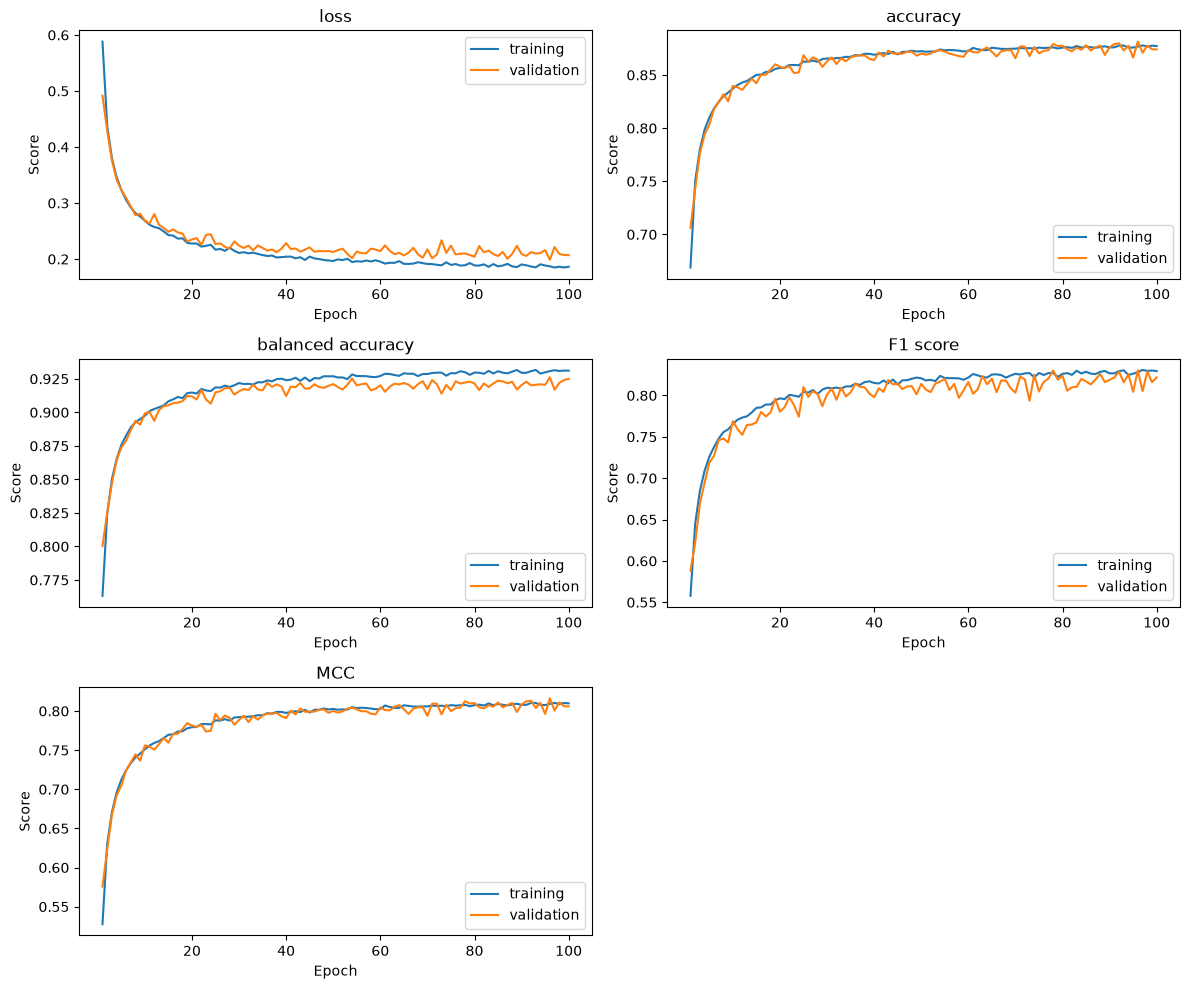

In [18]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

axs = axs.flatten()
metrics = [[model_val.train_epoch_losses, model_val.valid_epoch_losses], [model_val.train_epoch_accs, model_val.valid_epoch_accs],
           [model_val.train_epoch_bal_accs, model_val.valid_epoch_bal_accs], [model_val.train_epoch_f1scores, model_val.valid_epoch_f1scores], 
           [model_val.train_epoch_mccs, model_val.valid_epoch_mccs]]
    
titles = ["loss", "accuracy", "balanced accuracy", "F1 score", "MCC"]
epochs = [i+1 for i in range(len(model_val.train_epoch_losses))]

for i in range(5):
    axs[i].plot(epochs, metrics[i][0], label="training")
    axs[i].plot(epochs, metrics[i][1], label="validation")
    axs[i].set_title(titles[i])
    axs[i].set_xticks(range(20, len(epochs)+1, 20))
    axs[i].set_xlabel("Epoch")
    axs[i].set_ylabel("Score")
    axs[i].legend()

axs[5].axis('off')

plt.tight_layout()
plt.show()

Although the metric scores are still gradually increasing after 100 epochs, they begin to plateau at around 40. Any performance gains after this number of epochs are marginal. the model shows no obvious signs of overfitting.

In [19]:
y_pred = predict(model_val, X_test, y_test)
print("Test set: accuracy: {:.3f}, balanced accuracy: {:.3f}, F1 score: {:.3f}, MCC: {:.3f}".format(model_val.acc,
                                                                                          model_val.balanced_acc, 
                                                                                          model_val.f1score, 
                                                                                          model_val.mcc))

Test set: accuracy: 0.873, balanced accuracy: 0.919, F1 score: 0.815, MCC: 0.804


Performance on the test set is good across all the metrics, especially considering the simplicity of the model.